# DAY2 특징 추가 실험

기존 셀 분할과 CV를 고정하고 로그 수명·ΔQ 최솟값·용량·IR·온도·충전 조건을 단계별로 비교한다. 모델 선택은 Batch1 CV만 사용하고 고정한 선택 모델을 Hold-out과 Batch2에 적용한다. Batch2는 평가 이력이 있는 재평가로 구분한다.

**보고서 연결:** 이 노트북은 해당 실험 단계의 실행 기록이다. 기존 셀 분리와 프로토콜 분리 결과를 함께 해석한 전체 결론은 [DAY2 보고서](../outputs/day2/DAY2_REPORT.md)에 있다.


In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd().resolve()
if not (ROOT / "src/day2_experiments.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.day2_experiments import main
main()  # 결과가 존재하면 학습·평가를 반복하지 않음
OUT = ROOT / "outputs/day2/feature_experiments"
result = json.loads((OUT / "results.json").read_text())

Saved experiment already exists; inspect results.json instead of repeating evaluation.


## 1. 같은 분할에서 단계별 비교

기존 학습용 28개·Hold-out 8개와 동일 CV 폴드다. 각 단계의 최저 CV 후보와 같은 일반 선형 회귀의 점수를 함께 확인한다. 단계는 특징을 누적한 비교이며, 모든 개별 조합을 탐색한 결과는 아니다.

In [2]:
stages = pd.read_csv(OUT / "stage_comparison.csv")
display(stages[["stage", "title", "n_features", "model", "cv_mape_pct", "linear_cv_mape_pct", "cv_mape_std_pp"]].round(3))
print("CV 선택:", result["selected"])
display(pd.read_csv(OUT / "model_comparison.csv").head(10).round(3))

,stage,title,n_features,model,cv_mape_pct,linear_cv_mape_pct,cv_mape_std_pp
0,S0,기존: 원 수명·분산,1,linear,9.285,9.285,1.590
1,S1,로그 수명,1,linear,9.346,9.346,2.000
2,S2,+ ΔQ 최솟값,2,ridge_1,9.500,10.096,1.934
3,S3,+ 초기 용량 특징,5,ridge_1,7.698,7.903,0.864
4,S4,+ IR 변화율,6,ridge_10,8.333,10.318,1.137
5,S5,+ 온도 변화,8,elasticnet_0.01_0.5,8.176,11.988,1.505
6,S6,+ 충전시간 중앙값,9,elasticnet_0.01_0.5,8.109,11.254,1.216
7,S7,+ C1·전환 SOC·C2,12,elasticnet_0.01_0.5,8.255,15.281,1.127


CV 선택: S3_ridge_1


,rank,candidate,stage,title,target,model,n_features,cv_mape_pct,cv_mape_std_pp,oof_mape_pct,oof_mae,oof_rmse,oof_r2,convergence_warning_count,feature_names
0,1,S3_ridge_1,S3,+ 초기 용량 특징,log10,ridge_1,5,7.698,0.864,7.660,61.670,78.292,0.706,0,"log10_delta_Q_var,delta_Q_min,qd_initial_media..."
1,2,S3_elasticnet_0.01_0.5,S3,+ 초기 용량 특징,log10,elasticnet_0.01_0.5,5,7.848,0.930,7.822,63.506,80.856,0.686,0,"log10_delta_Q_var,delta_Q_min,qd_initial_media..."
2,3,S3_linear,S3,+ 초기 용량 특징,log10,linear,5,7.903,2.470,7.845,62.838,87.559,0.632,0,"log10_delta_Q_var,delta_Q_min,qd_initial_media..."
3,4,S3_elasticnet_0.01_0.1,S3,+ 초기 용량 특징,log10,elasticnet_0.01_0.1,5,7.926,1.011,7.884,63.288,80.597,0.688,0,"log10_delta_Q_var,delta_Q_min,qd_initial_media..."
4,5,S3_ridge_0.1,S3,+ 초기 용량 특징,log10,ridge_0.1,5,8.048,1.513,7.978,63.700,82.262,0.675,0,"log10_delta_Q_var,delta_Q_min,qd_initial_media..."
5,6,S6_elasticnet_0.01_0.5,S6,+ 충전시간 중앙값,log10,elasticnet_0.01_0.5,9,8.109,1.216,8.041,64.815,77.527,0.711,0,"log10_delta_Q_var,delta_Q_min,qd_initial_media..."
6,7,S3_elasticnet_0.001_0.5,S3,+ 초기 용량 특징,log10,elasticnet_0.001_0.5,5,8.158,1.357,8.084,64.377,82.072,0.676,0,"log10_delta_Q_var,delta_Q_min,qd_initial_media..."
7,8,S5_elasticnet_0.01_0.5,S5,+ 온도 변화,log10,elasticnet_0.01_0.5,8,8.176,1.505,8.107,65.740,82.686,0.672,0,"log10_delta_Q_var,delta_Q_min,qd_initial_media..."
8,9,S3_ridge_10,S3,+ 초기 용량 특징,log10,ridge_10,5,8.191,1.275,8.167,66.587,86.033,0.644,0,"log10_delta_Q_var,delta_Q_min,qd_initial_media..."
9,10,S3_elasticnet_0.001_0.1,S3,+ 초기 용량 특징,log10,elasticnet_0.001_0.1,5,8.216,1.629,8.147,65.020,84.284,0.659,0,"log10_delta_Q_var,delta_Q_min,qd_initial_media..."


## 2. 결과 해석

로그 수명 변환이나 ΔQ 최솟값 추가만으로는 CV가 개선되지 않았다. 초기 용량 특징을 추가한 S3 Ridge가 선택됐다. IR·온도·충전시간·충전 조건까지 누적한 단계는 S3를 넘지 못했다. 입력을 모두 넣는 것이 가장 좋은 전략은 아니었다.

,구분,MAPE (%),비고
0,Train (Batch 1 CV),7.698,동일 28개 셀·동일 5-fold 검증 MAPE 평균
1,Valid (Batch 1 Hold-out),3.421,8개 셀; 후보 선택에 사용하지 않음
2,Test (Batch 2),38.198,39개 셀; CV 선택 후 고정 모델 재평가
3,Gap (Train-Valid),-4.277,Valid − CV; %p
4,Gap (Valid-Test),34.776,Test − Valid; %p
5,Gap (Target-Test),29.098,Test − 9.1; %p; 참고 비교


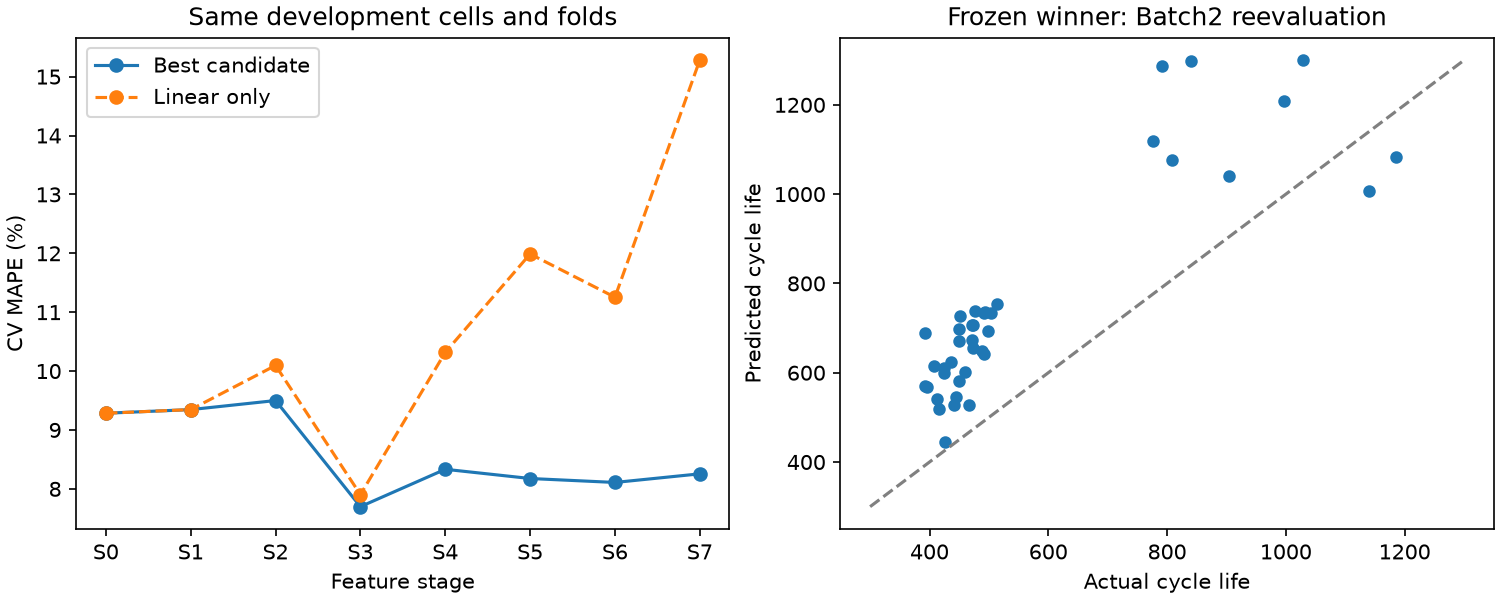

,evaluation,life_band,n,mape_pct,mean_residual
0,Test (Batch 2),<=500,28,40.018,-179.428
1,Test (Batch 2),500-1000,8,40.320,-297.311
2,Test (Batch 2),>1000,3,15.551,-11.985
3,Valid (Batch 1 Hold-out),500-1000,7,2.772,-9.333
4,Valid (Batch 1 Hold-out),>1000,1,7.969,83.990


In [3]:
display(pd.read_csv(OUT / "performance_reporting.csv").round(3))
display(Image(filename=str(OUT / "experiment_summary.png")))
display(pd.read_csv(OUT / "evaluation_segments.csv").round(3))

## 3. 외부 평가와 입력 차이

선택 모델은 CV 7.70%, Hold-out 3.42%였지만 Batch2는 38.20%였다. 기존 단일 특징 모델의 Batch2 26.19%보다 악화했다. 이 결과를 보고 다시 후보를 선택하지 않았다.

초기 QD 중앙값과 감소 기울기에 학습 범위를 벗어난 Batch2 셀이 많았다. 추가 특징이 Batch1에서는 유용했지만 배치별 초기 상태·측정 조건을 반영했을 가능성이 있다. 이러한 진단만으로 원인을 확정하지 않는다.

In [4]:
display(pd.read_csv(OUT / "selected_feature_diagnostics.csv").round(5))
manifest = pd.read_csv(OUT / "split_manifest.csv")
oof = pd.read_csv(OUT / "oof_predictions.csv")
assert not manifest.duplicated(["batch", "cell_id"]).any()
assert oof.batch.eq("Batch1").all()
assert oof.groupby("candidate").size().eq(28).all()
assert not result["test_used_for_selection"]
assert not result["holdout_used_for_selection"]
print("독립 셀 분리·학습 폴드 전처리·100사이클 입력·CV 선택 유지")

,feature,train_median,test_median,train_min,train_max,test_outside_train_n,coefficient_original_units,median_difference_contribution
0,log10_delta_Q_var,-3.79561,-3.48726,-4.17888,-3.35034,17,-0.18497,-0.05704
1,delta_Q_min,-0.03806,-0.05417,-0.06472,-0.02369,14,2.98735,-0.04812
2,qd_initial_median,1.08107,1.09749,1.05943,1.09827,19,3.47344,0.05706
3,qd_fraction_change,-0.00101,0.00107,-0.01090,0.00118,19,-3.29530,-0.00684
4,early_drop_per100,0.00151,-0.00218,-0.00133,0.01527,21,-0.53507,0.00198


독립 셀 분리·학습 폴드 전처리·100사이클 입력·CV 선택 유지


## 4. 한계와 재현

학습 수명 범위는 534–1,074사이클이다. 필요한 2017-06-30 후속 파일이 없어 연속 실험 5개 셀은 복구하지 못했다. Batch1 제공 수명 레이블의 한계와 기존 제외 기준도 유지했다.

71개 설정을 비교해 선택했으므로 CV는 낙관적일 수 있다. Hold-out과 Batch2에도 이전 평가 이력이 있어 새로운 독립 검증이라고 표현하지 않는다. seed, 버전, 규제 범위, 특징 계산, 데이터·분할·코드·모델 해시는 results.json에 기록한다. Batch3 평가나 운영 자동화는 수행하지 않았다.